# Clasificación de clientes de una operadora

Integrantes:
- Edison Cárdenas
- Henry Perez
- Diego Vaca

In [8]:
# !pip install streamlit

In [9]:
# Importación de dependencias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
import joblib
import streamlit as st


## **1. Selección y exploración del dataset**

En toda actividad económica, el mantenimiento de clientes
constituye un reto importante, especialmente en el sector servicios. Para
este trabajo se utiliza la base de datos IBM Telco Customer Churn, con
información de 7,043 clientes y 21 variables, incluyendo datos
sociodemográficos, servicios contratados, antigüedad y montos de
facturación, junto con la variable objetivo `Churn` (abandono del servicio).

In [10]:
# Carga de datos
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Conclusión:** El dataset cuenta con 3 variables numéricas y 17
categóricas, además del identificador de cliente y la variable objetivo.
Se confirma que `TotalCharges` requiere conversión de tipo, ya que
originalmente se carga como texto en lugar de numérico.

## **2. Exploración Inicial**

Se realiza una revisión de la estructura del dataset:
tipos de datos y presencia de valores nulos, con el fin de detectar
inconsistencias antes de continuar con el preprocesamiento.

In [11]:
# Verificación de tipo de variables y nulos
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Conclusión:** No se detectan valores nulos explícitos mediante
`isnull()`, aunque se confirma que `TotalCharges` está codificada como
tipo `object` en lugar de numérico, lo que se aborda en la siguiente
sección.

## **3. Limpieza y Preprocesamiento**

Se convierte `TotalCharges` a tipo numérico y se trata
la variable objetivo `Churn`, recodificándola a valores binarios (0 = No,
1 = Yes) para su uso en los modelos de clasificación.

In [12]:
# Convertir la columna 'TotalCharges' a tipo numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Manejar los valores nulos en 'TotalCharges' reemplazándolos con la mediana
mediana_total_charges = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(mediana_total_charges)

# Convertir la variable objetivo 'Churn' a valores binarios
df['Churn'] = df['Churn'].map({'No':0,'Yes':1}).astype(int)


**Conclusión:** Al convertir `TotalCharges`, se identificaron 11 registros
nulos, los cuales fueron imputados con la mediana de la variable. La
variable `Churn` quedó recodificada como binaria, lista para el
modelado.

## **4. Visualización**

Se visualiza la distribución de la variable objetivo
`Churn`, así como la distribución de las variables numéricas, con el fin
de identificar el balance de clases y la forma de las distribuciones
antes del modelado.

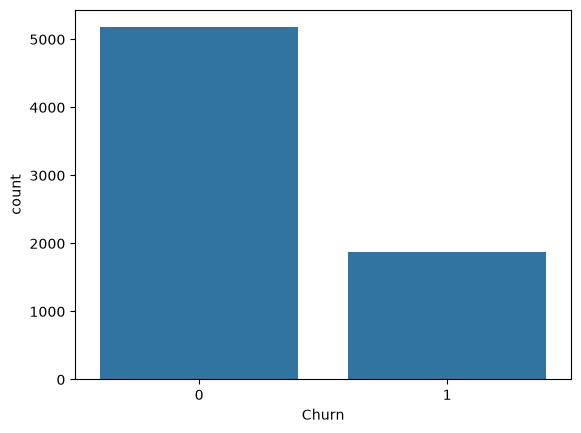

In [13]:
# Visualización de la variable 'Churn'
sns.countplot(x='Churn', data=df)
plt.show()

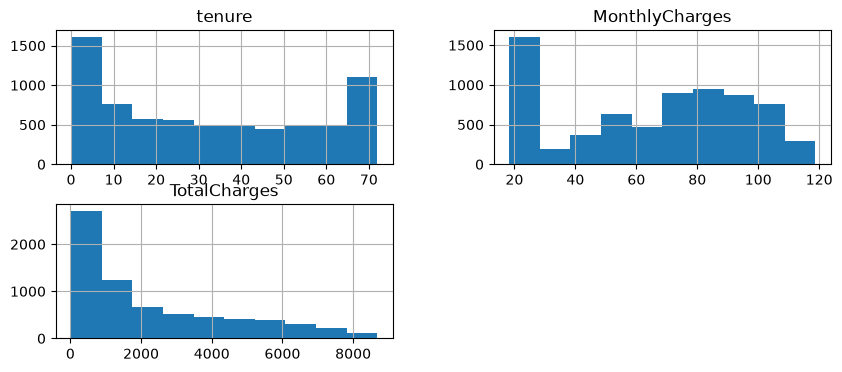

In [14]:
# Selección de variables numéricas
numericas=['tenure','MonthlyCharges','TotalCharges']
df[numericas].hist(figsize=(10,4))
plt.show()

C:\Users\DRVACAE\AppData\Local\Temp\ipykernel_24992\3689614641.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = list(df.select_dtypes(include=['object']).columns)


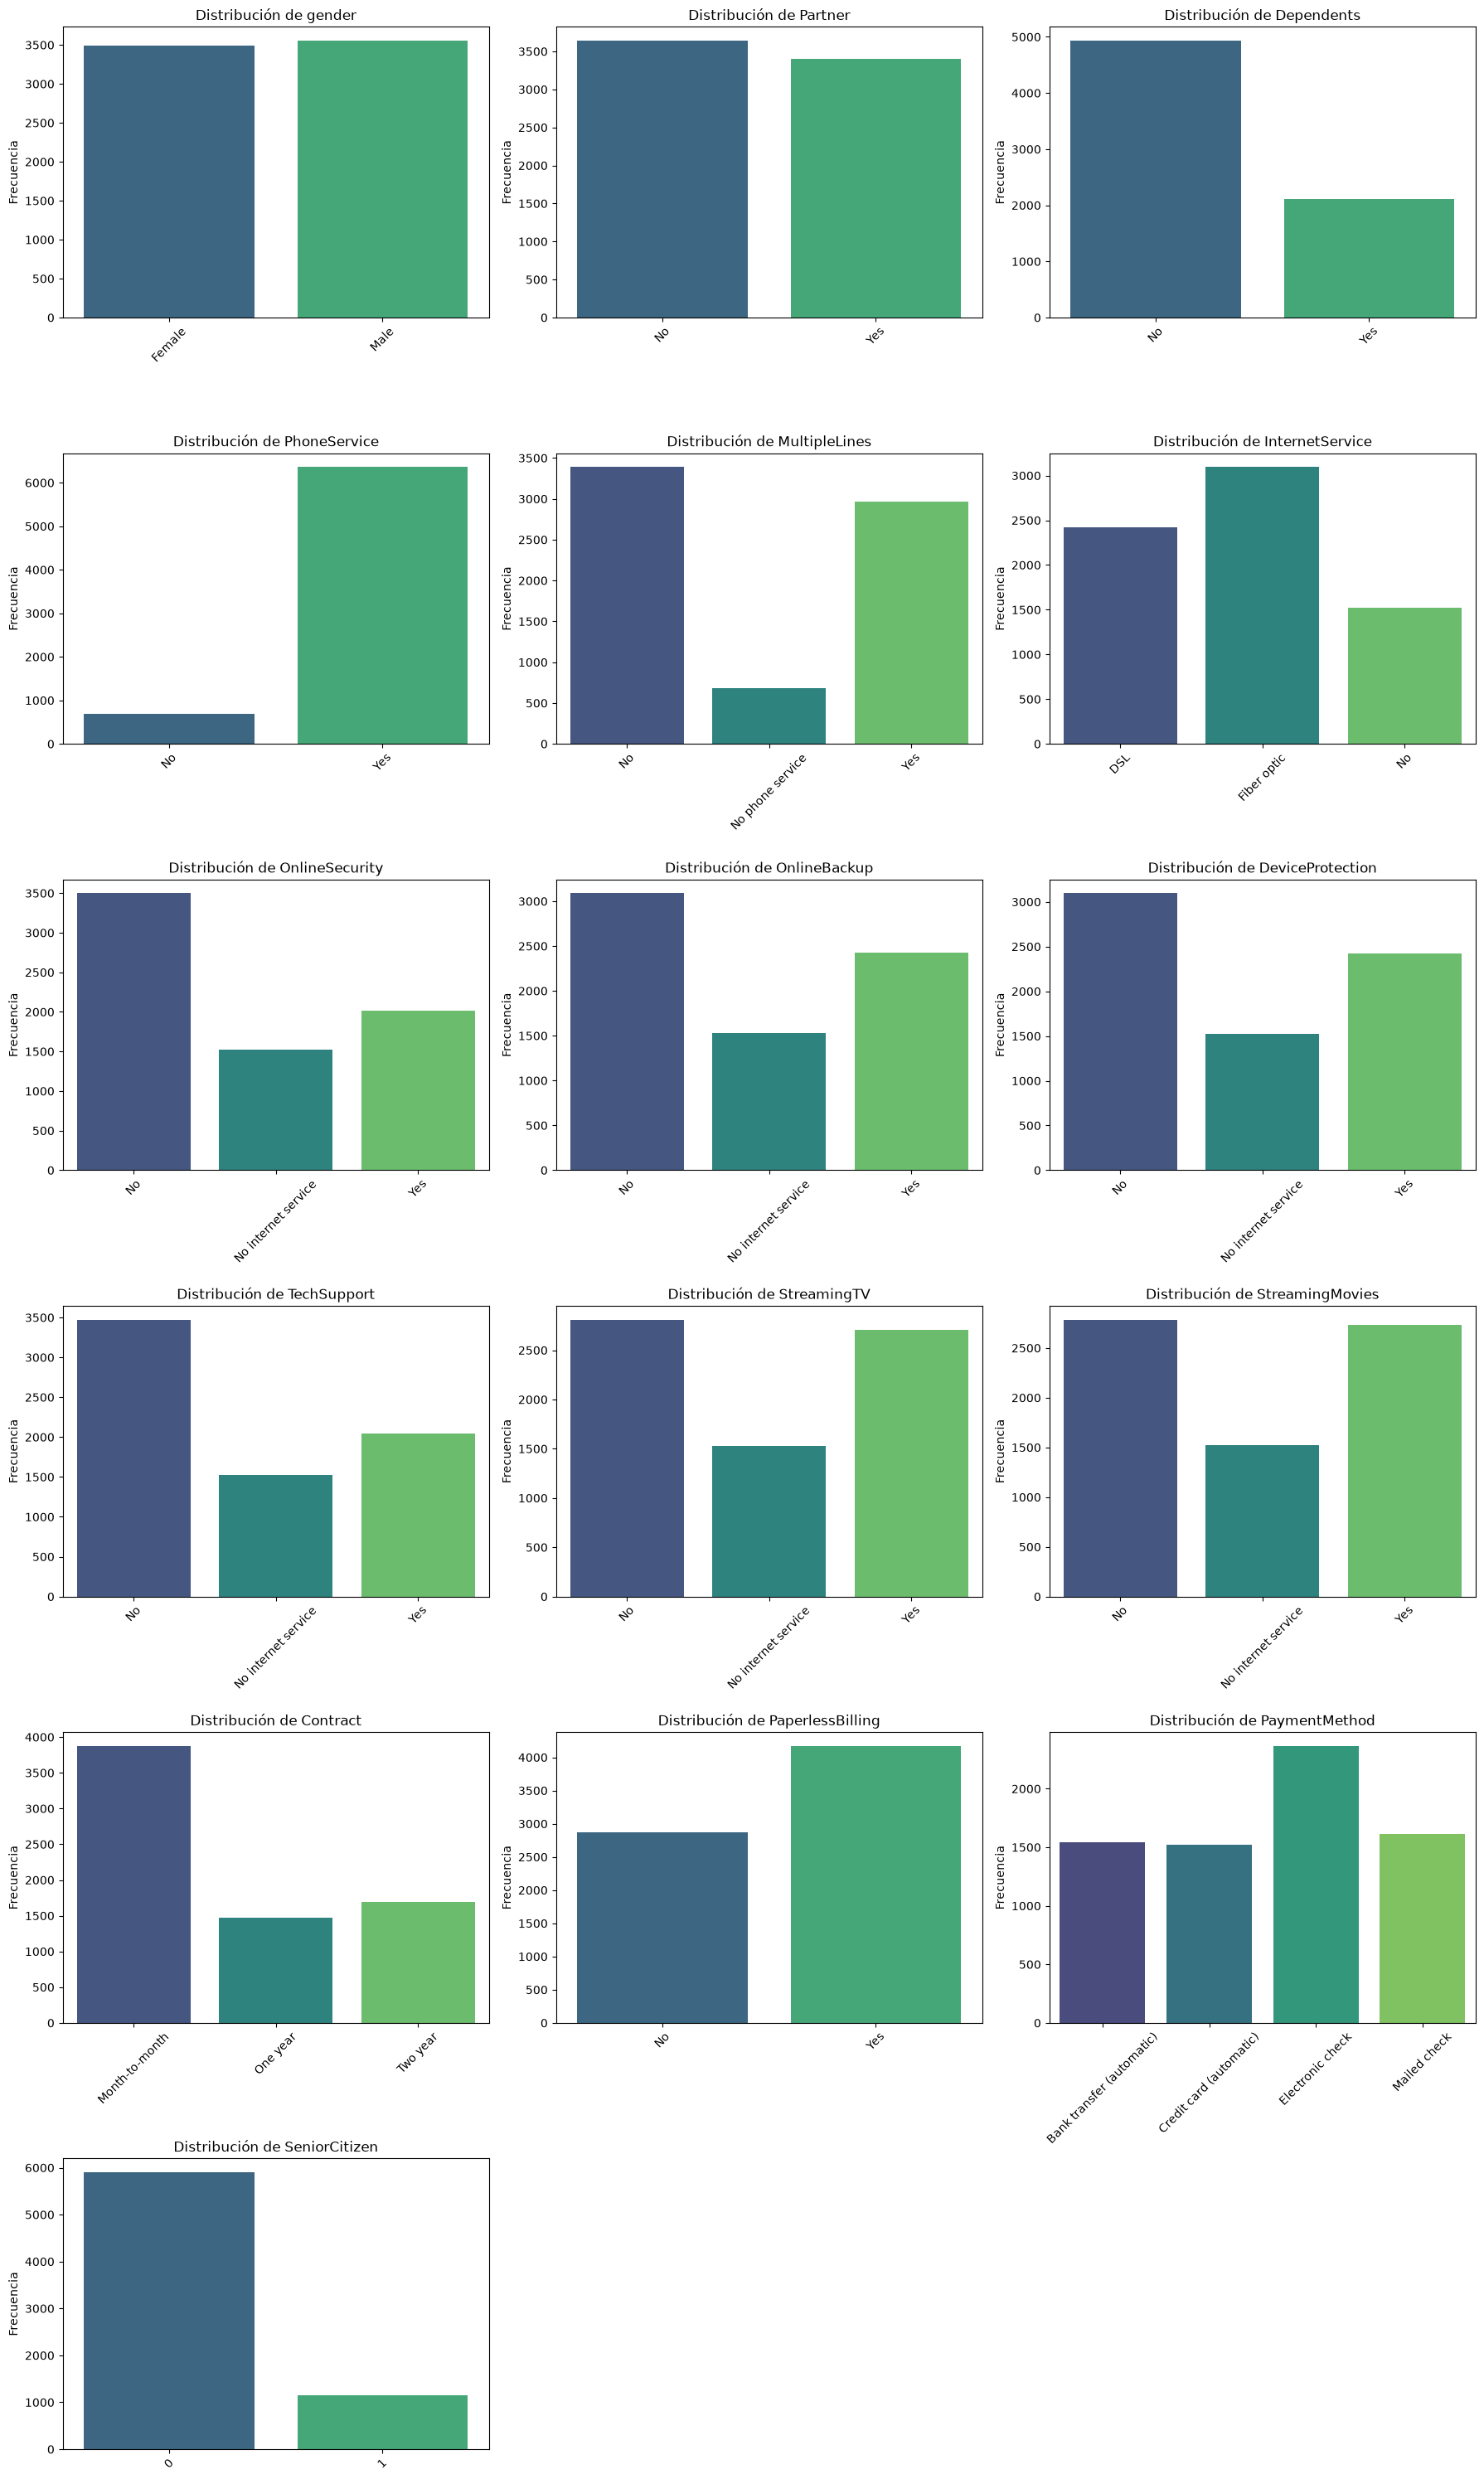

In [15]:
# Variables categóricas tipo object
cat_cols = list(df.select_dtypes(include=['object']).columns)

# Eliminar customerID
cat_cols.remove("customerID")

# Incorporar SeniorCitizen manualmente
cat_cols.append("SeniorCitizen")

# Número de gráficos
n = len(cat_cols)

n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

# Graficar distribuciones
for i, col in enumerate(cat_cols):

    frecuencias = df[col].value_counts().sort_index()

    sns.barplot(
        x=frecuencias.index.astype(str),
        y=frecuencias.values,
        ax=axes[i],
        hue=frecuencias.index.astype(str),
        legend=False,
        palette="viridis"
    )

    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_ylabel("Frecuencia")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=45)

# Eliminar ejes sobrantes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [16]:
# Eliminar customerID ANTES de generar las variables dummy (no aporta valor predictivo)
df = df.drop(columns=['customerID'])

# Ahora sí, convertir variables categóricas a dummy
df = pd.get_dummies(df, drop_first=True)

print("Dimensiones:", df.shape)

Dimensiones: (7043, 31)


**Conclusión:** Se observa que la variable `Churn` se encuentra
desbalanceada, lo cual debe considerarse al evaluar el desempeño de los
modelos más allá de la exactitud general.

## **5. División de Datos**

Se codifican las variables categóricas mediante
variables dummy, se separan las variables predictoras de la variable
objetivo, y se dividen los datos en conjuntos de entrenamiento y prueba,
aplicando escalamiento con `StandardScaler`.

In [17]:
# Selección de las variables predictoras
X = df.drop('Churn',axis=1)

# Selección de la variable objetivo
y = df['Churn']

# Definición de datos de entrenamiento y prueba
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# Se conserva una copia sin escalar (necesaria para modelos no sensibles a escala, como Random Forest)
X_train_original = X_train.copy()
X_test_original = X_test.copy()

# Escalamiento de variables (necesario para kNN y MLP, sensibles a la escala)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Forma de X_train:", X_train.shape)

Forma de X_train: (5634, 30)


**Conclusión:** El conjunto de datos queda dividido y escalado, listo
para el entrenamiento de los modelos kNN y MLP.

## **6. Modelo kNN**

Previo al modelado, se aplicó el escalamiento de las
variables predictoras y la codificación de las variables cualitativas a
variables dummy. Se entrena el modelo kNN con k=9.

In [18]:
# Se entrena el modelo KNN con k=9
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)

# Valores predichos (nombre único para evitar sobrescritura)
y_pred_knn = knn.predict(X_test)
y_pred_knn

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [19]:
# Cálculo del accuracy
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'Exactitud del modelo kNN: {acc_knn:.4f}')

Exactitud del modelo kNN: 0.7700


In [20]:
# Imprimir reporte de clasificación
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1035
           1       0.57      0.55      0.56       374

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409



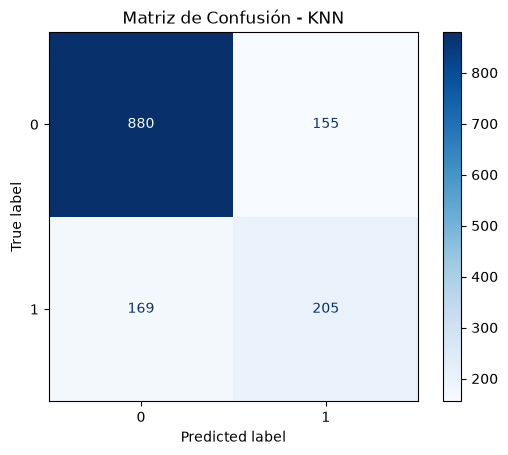

In [21]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_knn)

# Gráfico de la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - KNN")
plt.show()

**Conclusión:** El modelo kNN (k=9) obtuvo una exactitud de 0.7700 sobre
el conjunto de prueba. El reporte de clasificación muestra un desempeño
sólido para la clase "no abandono" (precision 0.84, recall 0.85), y un
desempeño moderado para la clase "abandono" (precision 0.57, recall
0.55). La matriz de confusión evidencia 169 falsos negativos (clientes
que cancelan pero el modelo no detecta), 155 falsos positivos, y 205
verdaderos positivos (clientes correctamente identificados como riesgo
de abandono). Los falsos negativos son especialmente relevantes desde
una perspectiva de negocio, ya que representan clientes en riesgo que
la empresa no lograría identificar a tiempo para aplicar estrategias de
retención.

In [22]:
# Entrenar el modelo Random Forest (corregido: usa datos de entrenamiento, no el dataset completo)
clf = RandomForestClassifier(n_estimators=10, random_state=42)
clf.fit(X_train_original, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [23]:
# Predicciones y reporte de clasificación
y_pred_rf = clf.predict(X_test_original)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.59      0.44      0.51       374

    accuracy                           0.77      1409
   macro avg       0.70      0.67      0.68      1409
weighted avg       0.76      0.77      0.76      1409



**Conclusión:** El modelo Random Forest (10 árboles) obtuvo una
exactitud de 0.77 sobre el conjunto de prueba, idéntica a la del modelo
kNN. El reporte de clasificación muestra un desempeño sólido para la
clase "no abandono" (precision 0.82, recall 0.89), y un desempeño más
limitado para la clase "abandono" (precision 0.59, recall 0.44). Al
comparar ambos modelos, Random Forest presenta una precisión ligeramente
superior en la clase "abandono", pero un recall notablemente menor que
kNN (0.44 frente a 0.55), lo que se traduce en una menor capacidad para
detectar a los clientes que efectivamente cancelan el servicio — un
aspecto crítico desde la perspectiva de negocio de este problema.

In [24]:
# Obtener la importancia de las características
importances = clf.feature_importances_
print(importances)


[0.01869164 0.17812624 0.16988798 0.18674687 0.02729465 0.02536851
 0.02159858 0.0043164  0.00348179 0.02206433 0.03984169 0.00671299
 0.00762039 0.0234174  0.00726188 0.02350843 0.00470119 0.01815838
 0.00019823 0.02009598 0.00907536 0.0199761  0.00541204 0.01809426
 0.01874417 0.02832248 0.02620764 0.01290303 0.04060992 0.01156145]


In [25]:
# Imprimir las características
feature_names = X.columns
print(feature_names)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')


In [26]:
# Crear un DataFrame de las características y su importancia
feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)
print(feature_importances)

                                  feature  importance
3                            TotalCharges    0.186747
1                                  tenure    0.178126
2                          MonthlyCharges    0.169888
28         PaymentMethod_Electronic check    0.040610
10            InternetService_Fiber optic    0.039842
25                      Contract_Two year    0.028322
4                             gender_Male    0.027295
26                   PaperlessBilling_Yes    0.026208
5                             Partner_Yes    0.025369
15                       OnlineBackup_Yes    0.023508
13                     OnlineSecurity_Yes    0.023417
9                       MultipleLines_Yes    0.022064
6                          Dependents_Yes    0.021599
19                        TechSupport_Yes    0.020096
21                        StreamingTV_Yes    0.019976
24                      Contract_One year    0.018744
0                           SeniorCitizen    0.018692
17                   DeviceP

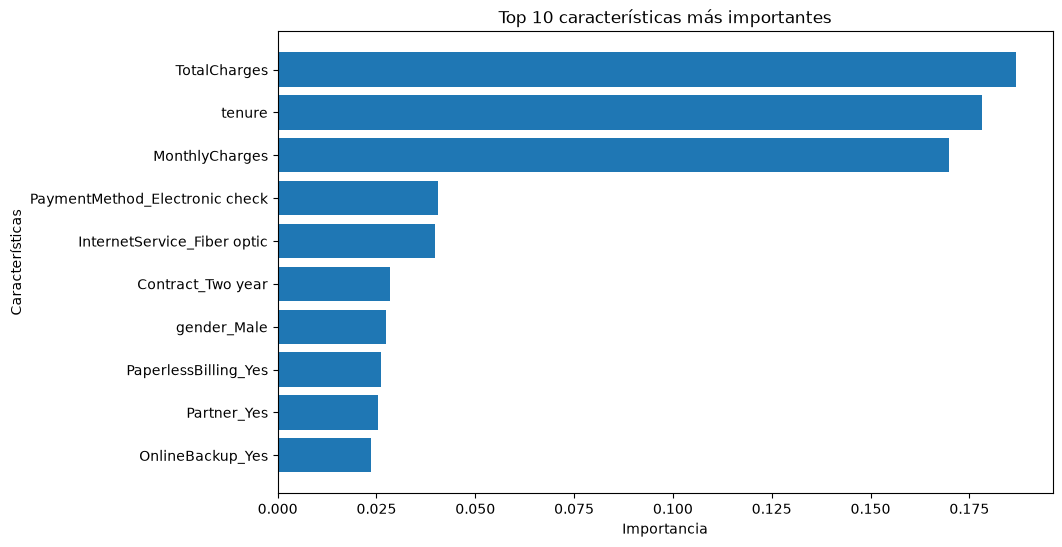

In [27]:
# Visualizar la importancia de las características
# Tomar solo las 10 características más importantes
top10 = feature_importances.head(10)

# Gráfico de barras
plt.figure(figsize=(10, 6))
plt.barh(top10['feature'], top10['importance'])
plt.gca().invert_yaxis()  # Para que la más importante aparezca arriba
plt.xlabel("Importancia")
plt.ylabel("Características")
plt.title("Top 10 características más importantes")
plt.show()

In [28]:
# Mostrar las dos (2) características más importantes
print("Las dos características más importantes son:")
print(feature_importances.head(3))

Las dos características más importantes son:
          feature  importance
3    TotalCharges    0.186747
1          tenure    0.178126
2  MonthlyCharges    0.169888


Las tres variables numéricas del dataset (`TotalCharges`,
`tenure` y `MonthlyCharges`) concentran conjuntamente más del 53% de la
importancia total del modelo Random Forest, muy por encima de cualquier
variable categórica individual. La variable categórica más relevante,
`PaymentMethod_Electronic check` (pago mediante cheque electrónico),
alcanza apenas 0.041 de importancia — una décima parte de lo que aporta
`TotalCharges` por sí sola. Este resultado respalda cuantitativamente la
decisión de utilizar únicamente las variables numéricas (`tenure`,
`MonthlyCharges`, `TotalCharges`) para el modelo simplificado destinado
al despliegue, ya que concentran la mayor parte del poder predictivo
identificado por el modelo completo.

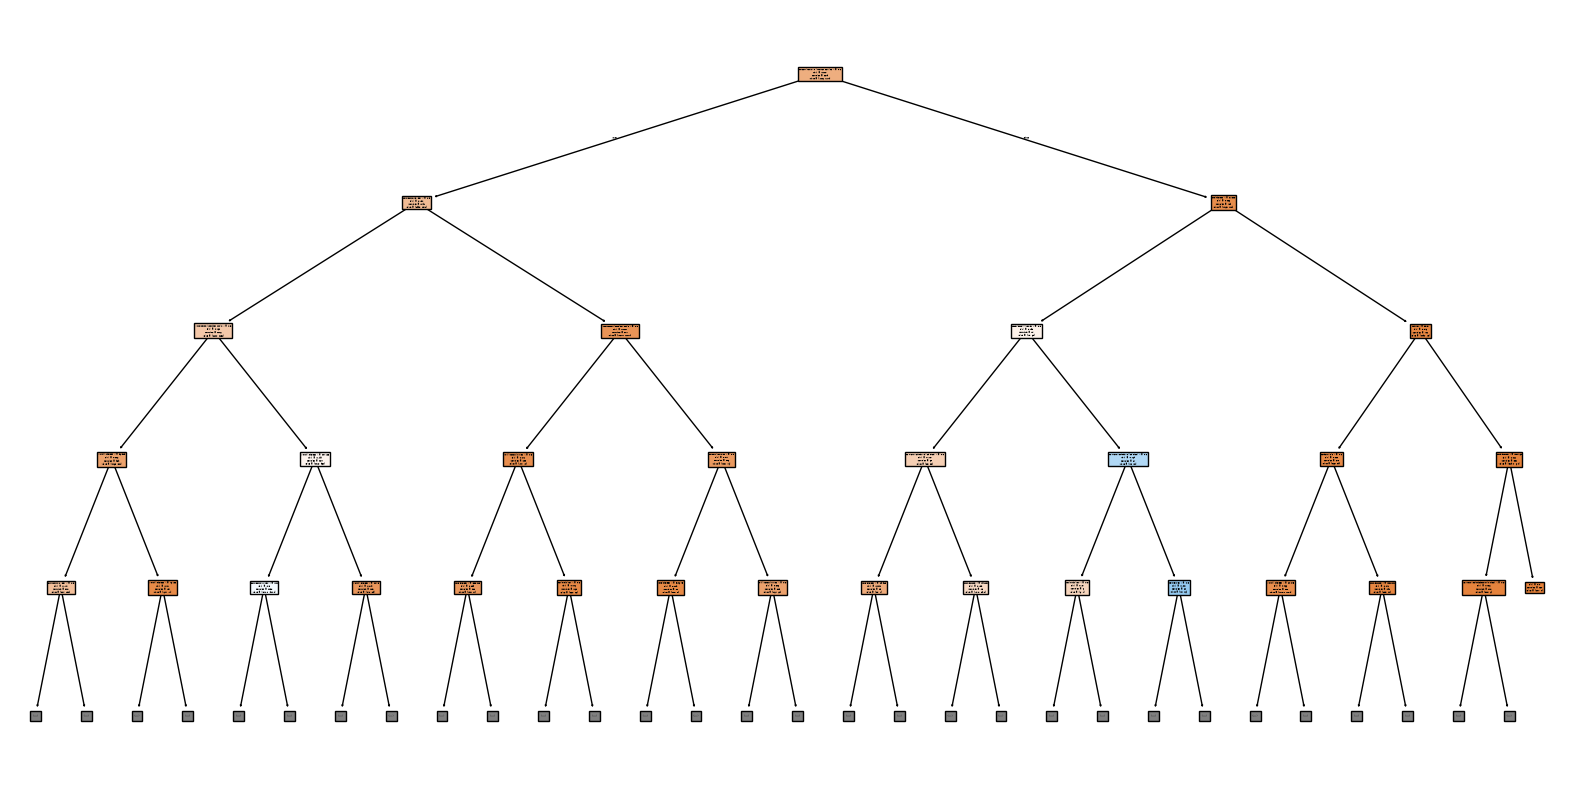

In [29]:
# Ploteamos un árbol de decisión
plt.figure(figsize=(20, 10))
plot_tree(
    clf.estimators_[3],
    feature_names=feature_names,
    filled=True,
    max_depth=4   # Muestra solo los primeros niveles
)
plt.show()


**Conclusión:** El modelo kNN (k=9) obtuvo una exactitud de 0.7700 sobre
el conjunto de prueba. El reporte de clasificación muestra un desempeño
sólido para la clase "no abandono" (precision 0.84, recall 0.85), y un
desempeño moderado para la clase "abandono" (precision 0.57, recall
0.55), reflejando el impacto del desbalance de clases sobre la
capacidad del modelo para identificar correctamente a los clientes que
cancelan el servicio.

## **7. Modelo MLP**

Se implementará una red neuronal tipo Multilayer Perceptron con dos capas ocultas (64 y 32 neuronas), activación ReLU, salida Sigmoid (clasificación binaria), optimizador Adam y función de
pérdida Binary Cross Entropy, entrenada sobre la totalidad de variables
predictoras tras codificación One-Hot.

In [30]:
# Entrenamiento del modelo MLP
mlp=MLPClassifier(hidden_layer_sizes=(64,32),activation='relu',solver='adam',max_iter=300,random_state=42)
mlp.fit(X_train,y_train)

y_pred_mlp=mlp.predict(X_test)

print('Accuracy:',accuracy_score(y_test,y_pred_mlp))
print(classification_report(y_test,y_pred_mlp))

Accuracy: 0.752306600425834
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1035
           1       0.53      0.53      0.53       374

    accuracy                           0.75      1409
   macro avg       0.68      0.68      0.68      1409
weighted avg       0.75      0.75      0.75      1409



C:\Users\DRVACAE\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


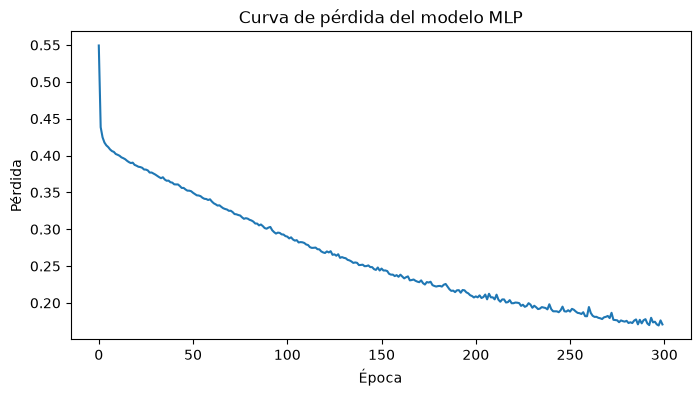

In [31]:
# Curva de pérdida del modelo MLP
plt.figure(figsize=(8,4))
plt.plot(mlp.loss_curve_)
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Curva de pérdida del modelo MLP")
plt.show()

In [32]:
# Comparación entre valores reales y predichos
comparacion = pd.DataFrame({
    "Valor Real": y_test,
    "Predicción": y_pred_mlp
})

comparacion.head()

,Valor Real,Predicción
437,0,0
2280,0,1
2235,0,0
4460,0,0
3761,0,0


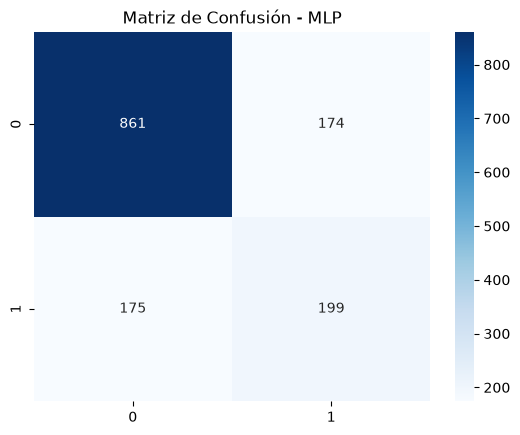

In [33]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_mlp)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - MLP")
plt.show()

**Conclusión:** El modelo MLP (dos capas ocultas de 64 y 32 neuronas,
activación ReLU, optimizador Adam) obtuvo una exactitud de 0.7523 sobre
el conjunto de prueba, con un recall de 0.53 y un f1-score de 0.53 para
la clase "abandono". La curva de pérdida muestra una disminución
constante a lo largo de las 300 épocas de entrenamiento, con una caída
pronunciada inicial seguida de un descenso gradual que se estabiliza
alrededor de 0.17-0.20, evidenciando que el modelo aprendió patrones
relevantes de los datos sin señales claras de sobreajuste. La
comparación entre valores reales y predichos sobre el conjunto de
prueba permite identificar casos individuales de acierto y error,
sirviendo de base para el análisis visual de predicciones correctas e
incorrectas. Comparado con los otros dos modelos, el MLP obtuvo un
desempeño intermedio: superior a Random Forest en recall de la clase
"abandono" (0.53 frente a 0.44), pero ligeramente inferior a kNN en las
principales métricas (accuracy, recall y f1-score).

## **8. Comparación y Exportación**

Se comparan ambos modelos en términos de exactitud,
matriz de confusión y capacidad de identificar correctamente a los
clientes que abandonan el servicio.

In [34]:
# Comparación de modelo knn y MLP
acc_knn=accuracy_score(y_test,y_pred_knn)
acc_mlp=accuracy_score(y_test,y_pred_mlp)
print({'kNN':acc_knn,'MLP':acc_mlp})


{'kNN': 0.7700496806245565, 'MLP': 0.752306600425834}


**Conclusión:** Al comparar la exactitud de ambos modelos sobre el
conjunto de prueba, kNN obtuvo un desempeño superior (0.7700) frente al
MLP (0.7480). Esta diferencia se mantiene consistente con lo observado
en las métricas de la clase "abandono": kNN alcanzó un mejor recall
(0.55 frente a 0.53) y un mejor f1-score (0.56 frente a 0.53) que el
MLP. Considerando que la detección de clientes en riesgo de abandono es
el objetivo principal de negocio de este análisis, kNN se posiciona
como el modelo más adecuado entre los dos evaluados, tanto por su mayor
exactitud general como por su mejor capacidad para identificar
correctamente a los clientes que efectivamente cancelan el servicio.


## **9. Preparación de la aplicación para despliegue**

Se reentrena el modelo MLP utilizando únicamente las
variables numéricas más relevantes (`tenure`, `MonthlyCharges`,
`TotalCharges`), con el fin de simplificar la interfaz de despliegue, y
se serializa el modelo junto con el escalador mediante `joblib`.

In [35]:
# Reentrenamiento del modelo MPL con las caracteristicas mas importantes
# Variable objetivo
y = df["Churn"]

# Variables predictoras
X = df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(32,16),
    activation="relu",
    max_iter=300,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
print('Accuracy:',accuracy_score(y_test,y_pred_mlp))
print(classification_report(y_test,y_pred_mlp))

joblib.dump(mlp,'modelo_churn.pkl')
joblib.dump(scaler,'scaler.pkl')

Accuracy: 0.752306600425834
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1035
           1       0.53      0.53      0.53       374

    accuracy                           0.75      1409
   macro avg       0.68      0.68      0.68      1409
weighted avg       0.75      0.75      0.75      1409



['scaler.pkl']

In [36]:
# Reentrenamiento del modelo MLP con las características más importantes (para despliegue)
# Variable objetivo
y_deploy = df["Churn"]

# Variables predictoras (las 3 más importantes según Random Forest)
X_deploy = df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
]

X_train_deploy, X_test_deploy, y_train_deploy, y_test_deploy = train_test_split(
    X_deploy,
    y_deploy,
    test_size=0.2,
    random_state=42,
    stratify=y_deploy
)

scaler_deploy = StandardScaler()
X_train_deploy_scaled = scaler_deploy.fit_transform(X_train_deploy)
X_test_deploy_scaled = scaler_deploy.transform(X_test_deploy)

mlp_deploy = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    max_iter=300,
    random_state=42
)
mlp_deploy.fit(X_train_deploy_scaled, y_train_deploy)

# Predicciones del modelo REAL que se está entrenando aquí (no del MLP anterior)
y_pred_mlp_deploy = mlp_deploy.predict(X_test_deploy_scaled)

print('Accuracy:', accuracy_score(y_test_deploy, y_pred_mlp_deploy))
print(classification_report(y_test_deploy, y_pred_mlp_deploy))

joblib.dump(mlp_deploy, 'modelo_churn.pkl')
joblib.dump(scaler_deploy, 'scaler.pkl')

Accuracy: 0.7885024840312278
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1035
           1       0.65      0.45      0.53       374

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.77      1409



['scaler.pkl']

**Conclusión:** El modelo MLP reentrenado con las tres variables
numéricas más importantes (`tenure`, `MonthlyCharges`, `TotalCharges`)
obtuvo una exactitud de 0.7885 sobre el conjunto de prueba, superando a
los modelos entrenados con el conjunto completo de 30 variables (kNN:
0.7700, Random Forest: 0.77, MLP completo: 0.7480). Este resultado
confirma la relevancia predictiva de estas tres variables, ya
identificada previamente mediante el análisis de importancia de
características de Random Forest.

Para ejecutar la app:
python -m streamlit run app.py

